In [ ]:
!apt-get install -y fonts-nanum > /dev/null

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from xgboost import XGBRegressor

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)

Mounted at /content/drive
로드 완료
train shape: (204000, 35)


In [ ]:
result_path = DATA_DIR + 'experiment_results.csv'

existing_results = pd.read_csv(result_path)
print('=== 기존 실험 결과 ===')
print(existing_results.to_string(index=False))

score_exp4 = existing_results[existing_results['실험번호'] == 4]['SMAPE'].values[0]
best_params = {'max_depth': 8, 'min_child_weight': 1,
               'subsample': 0.9, 'colsample_bytree': 0.9}

=== 기존 실험 결과 ===
 실험번호                 실험명     SMAPE       개선폭                                                                                         비고
    0 대회_Baseline_XGBoost 24.014000  0.000000                                                     대회 제공 Baseline, Feature Engineering 없음
    1          FE_XGBoost  8.424200 15.589800                                                                  Feature Engineering 추가 효과
    2         LightGBM_전체  9.388100 -0.963900                                                                            XGBoost보다 성능 낮음
    3         유형별_XGBoost  7.257900  2.130200                                                                            유형별 모델 분리 효과 확인
    4      유형별_XGBoost_튜닝  6.889891  0.368009 최적파라미터: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 0.9}
    5      건물별_XGBoost_튜닝  7.029944 -0.140053                                                                        100개 건물 각각 개별 모델 학습


In [ ]:
TRAIN_FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
    '일조(hr)', '일사(MJ/m2)',
]
TARGET = '전력소비량(kWh)'

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

val_mask_all   = train_df['일시'] >= '20240818 00'
train_mask_all = train_df['일시'] < '20240818 00'

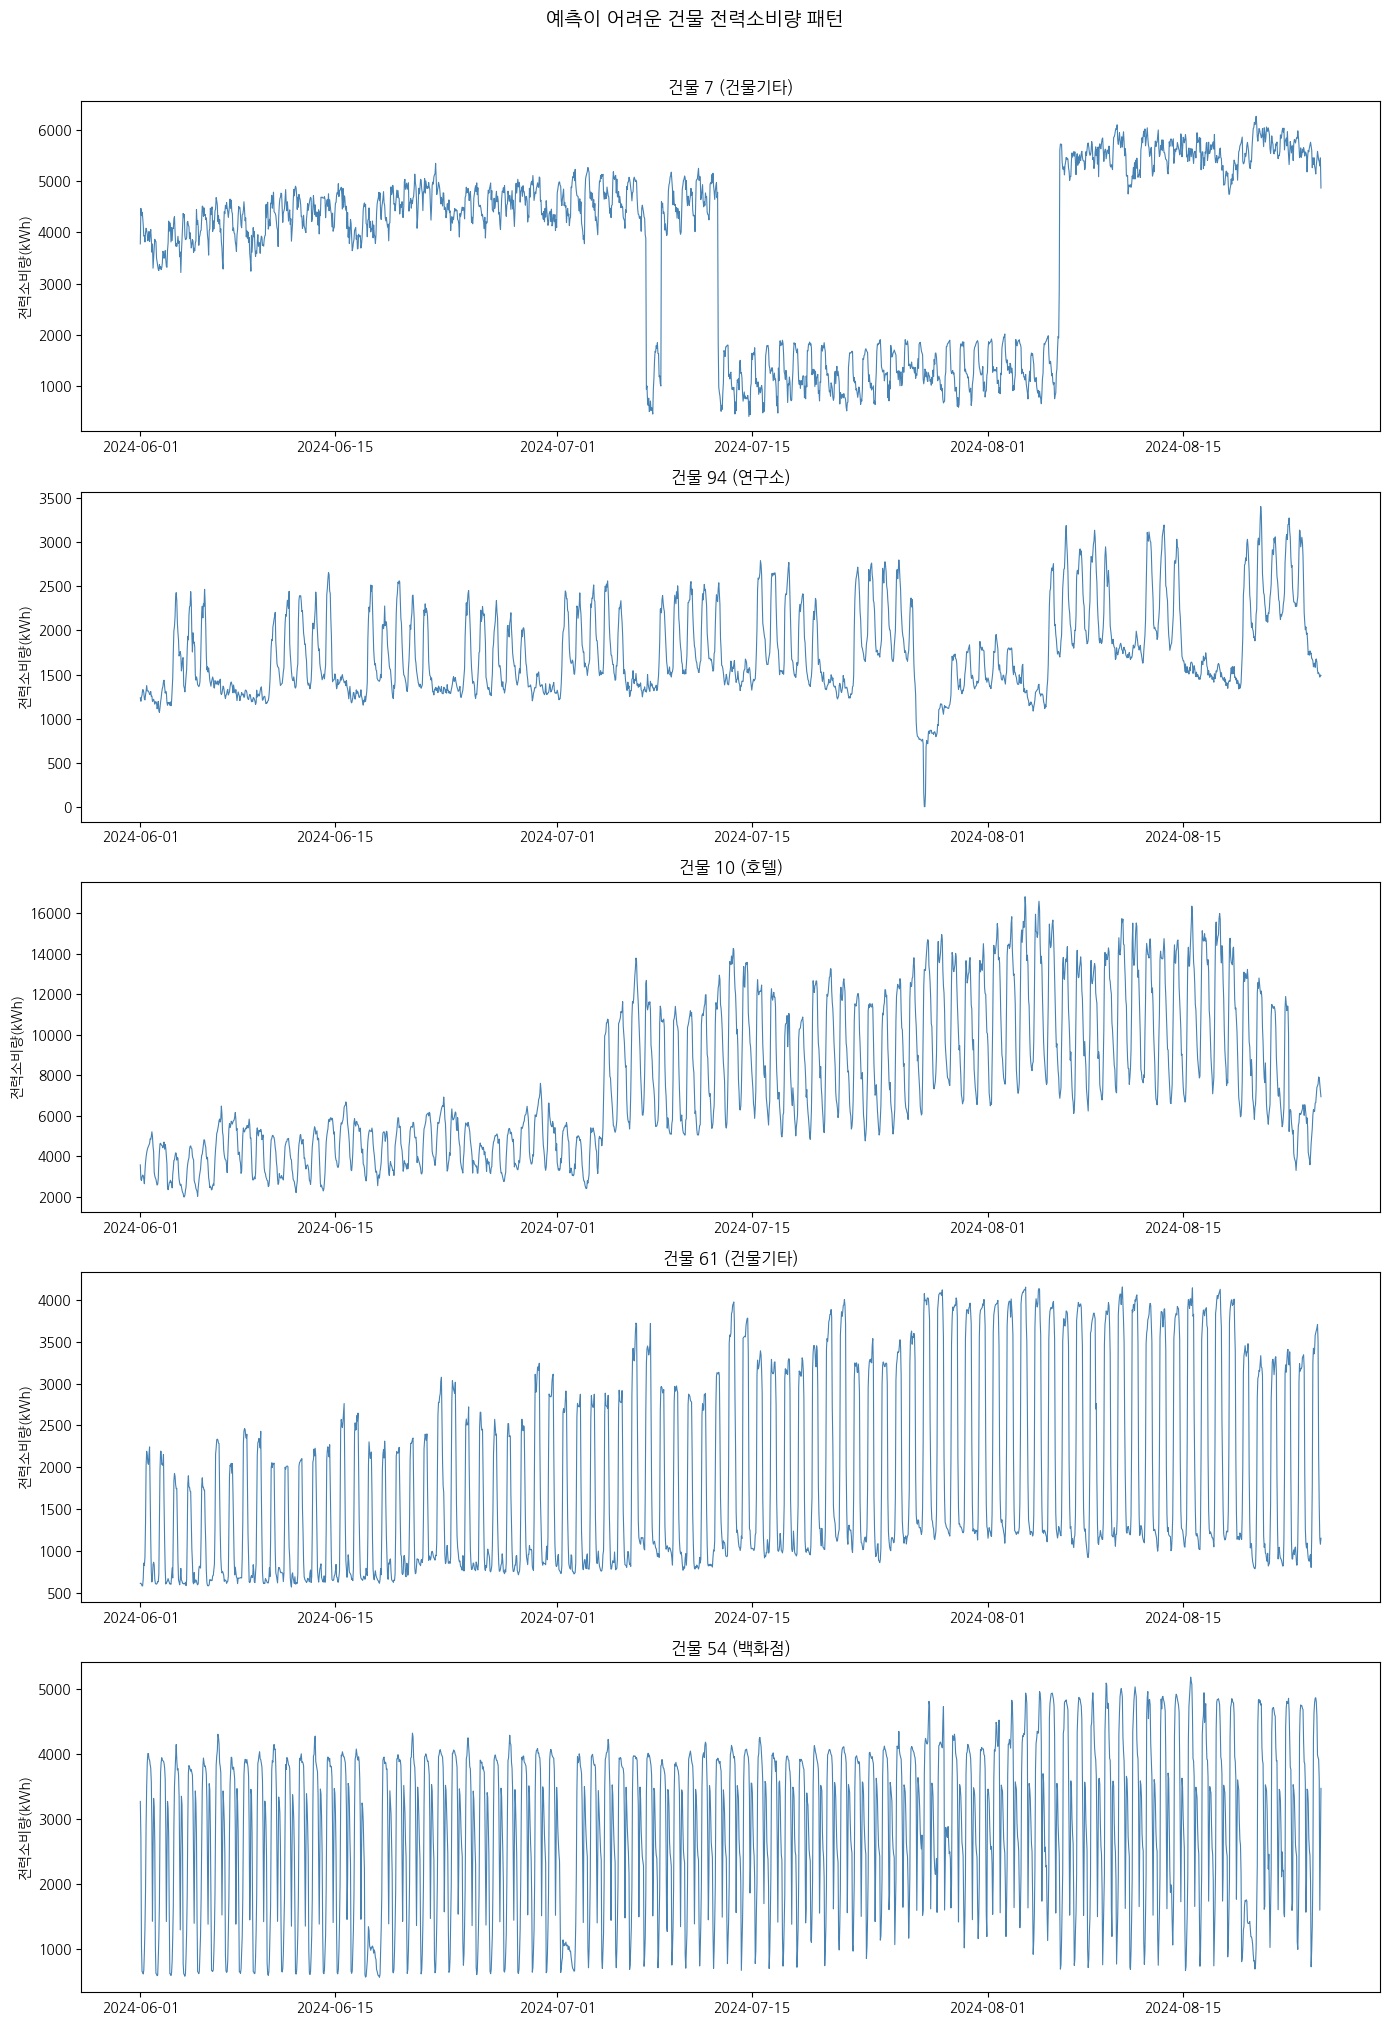

In [ ]:
# 실험 5에서 SMAPE가 높았던 건물들
# 직접 시각화해서 왜 예측이 어려운지 원인 파악
problem_buildings = [7, 94, 10, 61, 54]

fig, axes = plt.subplots(len(problem_buildings), 1, figsize=(14, 20))

for i, bnum in enumerate(problem_buildings):
    subset = train_df[train_df['건물번호'] == bnum].copy()
    subset['datetime'] = pd.to_datetime(subset['일시'], format='%Y%m%d %H')
    btype   = subset['건물유형'].values[0]

    axes[i].plot(subset['datetime'], subset['전력소비량(kWh)'],
                 linewidth=0.8, color='steelblue')
    axes[i].set_title(f'건물 {bnum} ({btype})')
    axes[i].set_ylabel('전력소비량(kWh)')

plt.suptitle('예측이 어려운 건물 전력소비량 패턴', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 시각화만으로는 부족하므로 수치로도 확인
print('=== 예측 어려운 건물 상세 통계 ===\n')

for bnum in problem_buildings:
    subset = train_df[train_df['건물번호'] == bnum]['전력소비량(kWh)']
    btype  = train_df[train_df['건물번호'] == bnum]['건물유형'].values[0]

    # 건물별 IQR 기준 이상치 계산
    Q1  = subset.quantile(0.25)
    Q3  = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    outliers     = subset[(subset < lower) | (subset > upper)]
    zero_count   = (subset == 0).sum()
    cv           = subset.std() / subset.mean()  # 변동계수 (높을수록 불규칙)

    print(f'건물 {bnum} ({btype})')
    print(f'  평균: {subset.mean():,.1f}  표준편차: {subset.std():,.1f}')
    print(f'  변동계수(CV): {cv:.3f}')
    print(f'  IQR 3배 기준 이상치: {len(outliers)}개')
    print(f'  전력소비량 0인 값: {zero_count}개')
    print()

=== 예측 어려운 건물 상세 통계 ===

건물 7 (건물기타)
  평균: 3,722.3  표준편차: 1,714.0
  변동계수(CV): 0.460
  IQR 3배 기준 이상치: 0개
  전력소비량 0인 값: 0개

건물 94 (연구소)
  평균: 1,748.9  표준편차: 499.4
  변동계수(CV): 0.286
  IQR 3배 기준 이상치: 0개
  전력소비량 0인 값: 2개

건물 10 (호텔)
  평균: 7,733.3  표준편차: 3,686.0
  변동계수(CV): 0.477
  IQR 3배 기준 이상치: 0개
  전력소비량 0인 값: 0개

건물 61 (건물기타)
  평균: 1,859.2  표준편차: 1,128.3
  변동계수(CV): 0.607
  IQR 3배 기준 이상치: 0개
  전력소비량 0인 값: 0개

건물 54 (백화점)
  평균: 2,877.6  표준편차: 1,224.4
  변동계수(CV): 0.426
  IQR 3배 기준 이상치: 0개
  전력소비량 0인 값: 0개

